In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
import phd_parser as pp

In [3]:
from phd_parser.raman.renishaw import read_export_txt, read_export_wdf

In [4]:
mock_txt_785 = Path(r"..\tests\raman\renishaw\TiO2_Julius_785_1acc_01.txt")
mock_txt_532 = Path(r"..\tests\raman\renishaw\TiO2_Julius_532_1acc_01.txt")
mock_wdf = Path(r"..\tests\raman\renishaw\TiO2_Julius_532_1acc_01.wdf")

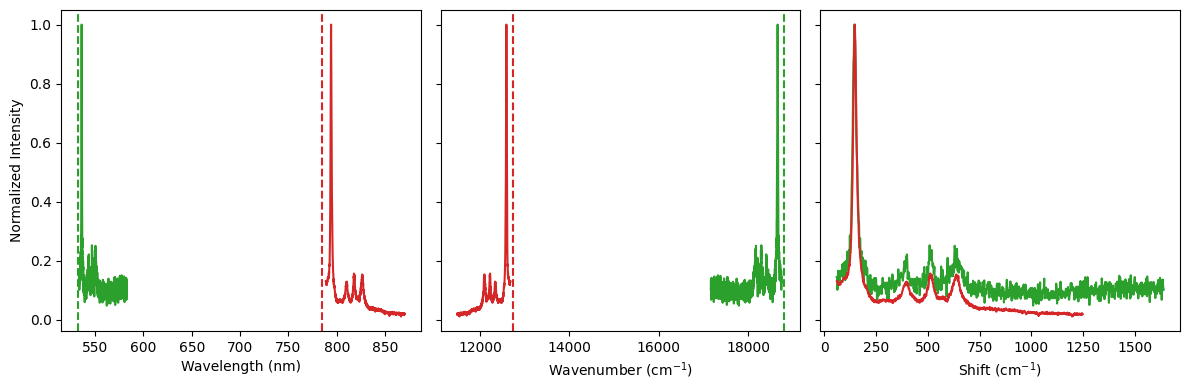

In [5]:
raman_txt_785 = pp.raman.RamanData.from_renishaw_txt(mock_txt_785, excitation_wavelength_nm=785)
raman_txt_532 = pp.raman.RamanData.from_renishaw_txt(mock_txt_532, excitation_wavelength_nm=532)

fig, axes = plt.subplots(1, 3, figsize = (12, 4),  sharey=True)
ax = axes.flatten()[0]
ax.plot(raman_txt_532.wavelength_nm,  raman_txt_532.values / np.max(raman_txt_532.values), label="532 nm", color = "tab:green")
ax.axvline(raman_txt_532.excitation_wavelength_nm, color="tab:green", linestyle="--", label="532 nm excitation")
ax.plot(raman_txt_785.wavelength_nm, raman_txt_785.values / np.max(raman_txt_785.values), label="785 nm", color = "tab:red")
ax.axvline(raman_txt_785.excitation_wavelength_nm, color="tab:red", linestyle="--", label="785 nm excitation")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalized Intensity")

ax = axes.flatten()[1]
ax.plot(raman_txt_532.wavenumber_per_cm,  raman_txt_532.values / np.max(raman_txt_532.values), label="532 nm", color = "tab:green")
ax.axvline(raman_txt_532.excitation_wavenumber_per_cm, color="tab:green", linestyle="--", label="532 nm excitation")
ax.plot(raman_txt_785.wavenumber_per_cm, raman_txt_785.values / np.max(raman_txt_785.values), label="785 nm", color = "tab:red")
ax.axvline(raman_txt_785.excitation_wavenumber_per_cm, color="tab:red", linestyle="--", label="785 nm excitation")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")

ax = axes.flatten()[2]
ax.plot(raman_txt_532.shift_per_cm,  raman_txt_532.values / np.max(raman_txt_532.values), label="532 nm", color = "tab:green")
ax.plot(raman_txt_785.shift_per_cm, raman_txt_785.values / np.max(raman_txt_785.values), label="785 nm", color = "tab:red")
ax.set_xlabel("Shift (cm$^{-1}$)")

plt.tight_layout()
plt.show()

In [ ]:
import spectrochempy as scp

"<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAABgAAAAYCAYAAADgdz34AAAA AXNSR0IArs4c6QAAAAlwSFlzAAAJOgAACToB8GSSSgAAAetpVFh0WE1MOmNvbS5hZG9iZS54bXAAAAAA ADx4OnhtcG1ldGEgeG1sbnM6eD0iYWRvYmU6bnM6bWV0YS8iIHg6eG1wdGs9IlhNUCBDb3JlIDUuNC4w Ij4KICAgPHJkZjpSREYgeG1sbnM6cmRmPSJodHRwOi8vd3d3LnczLm9yZy8xOTk5LzAyLzIyLXJkZi1z eW50YXgtbnMjIj4KICAgICAgPHJkZjpEZXNjcmlwdGlvbiByZGY6YWJvdXQ9IiIKICAgICAgICAgICAg eG1sbnM6eG1wPSJodHRwOi8vbnMuYWRvYmUuY29tL3hhcC8xLjAvIgogICAgICAgICAgICB4bWxuczp0 aWZmPSJodHRwOi8vbnMuYWRvYmUuY29tL3RpZmYvMS4wLyI+CiAgICAgICAgIDx4bXA6Q3JlYXRvclRv b2w+bWF0cGxvdGxpYiB2ZXJzaW9uIDIuMS4wLCBodHRwOi8vbWF0cGxvdGxpYi5vcmcvPC94bXA6Q3Jl YXRvclRvb2w+CiAgICAgICAgIDx0aWZmOk9yaWVudGF0aW9uPjE8L3RpZmY6T3JpZW50YXRpb24+CiAg ICAgIDwvcmRmOkRlc2NyaXB0aW9uPgogICA8L3JkZjpSREY+CjwveDp4bXBtZXRhPgqNQaNYAAAGiUlE QVRIDY1We4xU1Rn/3XPuYx47u8w+hnU38hTcuoUEt/6D2y4RB0ME1BoEd9taJaKh9CFiN7YGp7appUAM NmktMZFoJTYVLVQ0smsy26CN0SU1QgsuFAaW3WVmx33N677O6XfuyoIxTXqSO/fec+75fd93vt/3/UbD V0aKSZmCpkFMLz3T9utuu2N+o98aDSMBKVAo89z5y+zEz3ZafcCOfvWdlGCalqKn1Bf71CygTd+mf1es SOnpdMpTb+vWpTZuWVfe3jLPa5tzHYNm0T5N0gpdkkHaDBeGBU6d1/t/fyS8+/CbqdfUvmsx1PuMgc2b Nxv79u1zgd31r+7JH1jbIZKxWRXAcYUQ8IWvBfBXNjEuJWPgMA02NR7C3/pYT9fjdZ3A9tGrWF8YSJHn qcDz3y7q2T967PZv+gnYJdd1mEZ+62zGDQV/dQgKhmLzDNOXCEWM3j6eTT5Y3w78dOBKJLR1PQf+4ivP j76UPZnssBN+wbM9Aet/AV81Mf1EEULXYfOobvX2WWQk0aoioXwwSmirOlioY0mu8BIouzYl7P8GV3vp qCCEZvlFz769w08oLDWvyKIyL1asSm28d6WfzA97ztvvV1kexUMsmhlkULEkuGYmFYC6AvfUrITnwUKl 5K79lkjeSSRRTCTbQPd95e1WzMbZSya74XoXAxctCllCnbECMOjZNGRwvzIXnD85wbkMmKK+U045Dtdi 8Qp+SAxU2GTg2bYlC9224pgvmSb54vkVTBQYyhUt2KjAMyMmPjwRQW5Mh2WKwJhlBh6jVGagFM84wZnQ 4bpC0Rt4pk1PbSt0NDcxDA5xryosDHWgtbM0DGZDWLSoiDMDYeQnGVrmOThxLozB0RAaahzkJzjKNqcI QBymJFMkOlN8Dqjpg0XYTx5xO/QbmmUrqIjGJznq47TqTaClKYfjp+PInLMwnOdYvtQBZ2XcunQY+VwI o4U4muoFEjVEFE6lQyEUKzHYfgQG9ylCyngU+CxjtOqxCDGHcCsOMCs6iQul5ZiStdATYxjMZXDLTUVw LY8Jey4uOh2IxjwsrP8UXJYxUrkZrghBahzV5iXU6gNkq0Z1EzIsUBUSCV2nEOHo0LVxHCpuxabJJdhi 5PFnvw5vLXwXIfNZvD/+JNo/X40NegE54sUaazl+UL8XD1x+FB9Ijjt4EQfdGN6J/x131LwIV9ap/AYs 0x1fz1ZKFbh6A7qKy/By9Dg6G36Ep91vUJJ15Cqr0Z67E8/HzmBrw1OwxWyM+3Mo6BAuSB17oyfx0Oyl 2DN0Hqs/70Cx6hBCvESFUY1ShWXZZEE7OTAYxZzaPH4TuoiusZvRnunFy2NbiHYuBp2vB66srX4vMEjp RKPxKXmnoQ4+Mn4DPiv8CYcrs3GfNUXJLtM+alSOhrMj/KT+wBNW3+E/2liywNO3iSflbaFva/+stGDT xE0E9Sjaox8HBhxpEamzMGSEaFKg+mjEddzDh1MxTDq3YV1kGBsjfwW3S9Cqanjmko+ndlb1UR3s6K8J lfphNWq9Ew/7c61T2BB/EbcaNkb8GBaE0tANH7/M34PLdhJDzjIcL9xPbdTG6zyM72Y+wXPHmvB489No fm0b5HnbQ9Rgp/7DSSd29AeVvPeNyK6JcYl/yQVi5dBjuGvoV/gaJe47s45QUxrDmcYX0MBsdF7egvXZ 7+O0vZA4X8QmOQWjlSK7RDz5wIM30gp9UbWcGjXxhzdDu1SiNSpx6kcQB57rPnr/3dlkZarWLnlRq5oP ET1dOCIOk4wALib9eeS5iygfhkd09H0DWphB/+gs+PcOAS+ssrFmmXXgVfR0de9cpbAJfH3Q1jofW9DZ k56dDcVsq9YcsoUMEd1qyLoT3BX1YiyHMJuk97hyjqIoE91t+NcTLeN0ZrfMoXatZbu6G0h4VG+ibqq0 IJVK6cAjo6serG3vSUezCMct0yQeSOFJSUImqb2qbknUpDqlZxE0QZ+ZUpSlZx79h4Nda6zef9dlk121 JDjbR5XggPRZlRnS6bRQRtLpn4++cuie/Yvn2svmNxuLw9WCcYIl4fEoTEGiSTUqJdfgU+8ROqf1iMkL zS389YtNPXc/PH8l8ONBJZkHD+4JtD04HmVEDWWErmBhzV2/2LB1bemJG6krzv2S6NOHUgtEP0Oif5pE /3fHoruP7N8RiP61GArzSwbUhJJQpXJKiKbfr/3bIhKq76sKPUdF9NW/LSqfSn6vjv8C45H/6FSgvZQA AAAASUVORK5CYII=' style='height:25px; border-radius:12px; display:inline-block; float:left; vertical-align:middle'>",SpectroChemPy's API - v.0.8.1©Copyright 2014-2026 - A.Travert & C.Fernandez @ LCS


In [ ]:
tio2_path = "C:\\Users\\jsommer1\\Delft University of Technology\\CE Atsushi-Julius Students - General\\MEP_Siddhant Kumar\\Characterization\\RAMAN\\2026-07-15\\red785\\2026-07-15_785_TiO2.wdf"
scp_raman = scp.read_wdf()
scp_raman

NDDataset: [float64] pp (shape: (y:1, x:1015))

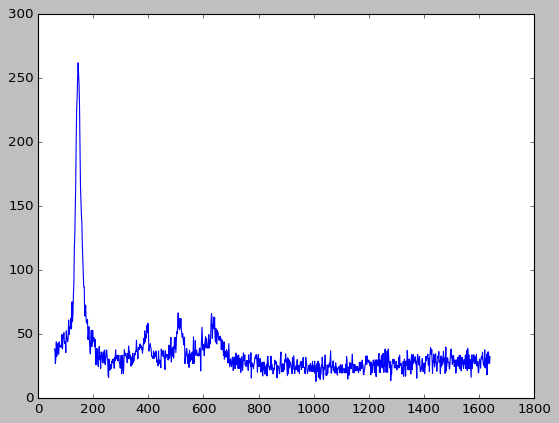

In [ ]:
raman_wdf = pp.raman.RamanData.from_renishaw_wdf(mock_wdf)
fig, ax = plt.subplots()
ax.plot(raman_wdf.shift_per_cm, raman_wdf.values)

In [ ]:
wdf = raman_wdf.metadata["WDFResult"]

In [ ]:
wdf.data

array([32.09693146, 26.74744415, 28.52114677, ..., 26.6658802 ,
       37.88819885, 37.88278961], shape=(1017,))

In [ ]:
mew = (wdf.laser_cm1 - wdf.wavenumber)

In [ ]:
wavelength = 1e7 / mew
wavelength

array([582.91751125, 582.87145704, 582.82534375, ..., 533.83736478,
       533.78822098, 533.73908623], shape=(1017,))